In [2]:
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tqdm import tqdm

projectPath = Path.cwd().parents[1]
print(projectPath)

c:\Users\Hannes\projects\paper-revision


In [3]:
datapath = projectPath / "data" / "z_norm"
df = pd.read_parquet(projectPath / "data" / "ivdata.parquet")

In [4]:
def getSlice(data, keys, idx):
    if isinstance(data, pd.api.typing.DataFrameGroupBy):
        date, texp = keys[idx]
        slicedf = data.get_group((date, texp))
        y = slicedf["z"].to_numpy(), slicedf["w"].to_numpy(),
        return y
    
    return data[idx, :]

def plotClustersSingle(labels, sliceMatrix, title, medoids):
    x = np.arange(sliceMatrix.shape[1])

    clusters = np.sort(np.unique(labels))
    n_clusters = len(clusters)

    n_cols = min(3, n_clusters)
    n_rows = int(np.ceil(n_clusters / n_cols))

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    fig, ax = plt.subplots(
        1,
        1,
        # figsize=(5 * n_cols, 4 * n_rows),
        sharex=True,
        sharey=True
    )

    for idx, cluster in enumerate(clusters):
        cluster_data = sliceMatrix[labels == cluster]
        if len(cluster_data) == 0:
            ax.set_title(f"Cluster {cluster} (empty)")
            continue
        
        elif len(cluster_data) == 1:
            mean = cluster_data[0]
            std = np.zeros_like(mean)
        else:
            mean = np.nanmean(cluster_data, axis=0)
            std = np.nanstd(cluster_data, axis=0)

        ax.fill_between(x, mean - std, mean + std, alpha=0.3, label="±1 std", color=colors[idx % len(colors)])
        if medoids is None:
            ax.plot(x,mean, linewidth=2, label="Mean", color=colors[idx % len(colors)])
        else:
            ax.plot(x, sliceMatrix[medoids[cluster]], linewidth=2, label="medoid", color=colors[idx % len(colors)])
        ax.set_title(f"Cluster {cluster}\nN={len(cluster_data)}")
        ax.grid(alpha=0.3)

        if cluster == clusters[0]:
            ax.legend()

    ax.set_xlabel("Profile coordinate")
    ax.set_ylabel("Value")

    fig.suptitle(f'Cluster Group: {title}')

    plt.tight_layout()
    # plt.savefig(projectPath / "images/TETS.png")
    plt.show()

def plotClusters(labels, sliceMatrix, title, medoids):
    x = np.arange(sliceMatrix.shape[1])

    clusters = np.sort(np.unique(labels))
    n_clusters = len(clusters)

    n_cols = min(3, n_clusters)
    n_rows = int(np.ceil(n_clusters / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        sharex=True,
        sharey=True
    )

    axes = np.atleast_1d(axes).flatten()

    for ax, cluster in zip(axes, clusters):
        cluster_data = sliceMatrix[labels == cluster]
        if len(cluster_data) == 0:
            ax.set_title(f"Cluster {cluster} (empty)")
            continue
        
        elif len(cluster_data) == 1:
            mean = cluster_data[0]
            print(cluster_data)
            std = np.zeros_like(mean)
        else:
            mean = np.nanmean(cluster_data, axis=0)
            std = np.nanstd(cluster_data, axis=0)

        # if show_individual:
        #     for curve in cluster_data:
        #         ax.plot(x, curve, alpha=0.1)

        ax.fill_between(x, mean - std, mean + std, alpha=0.3, label="±1 std")
        if medoids is None:
            ax.plot(x,mean, linewidth=2, label="Mean")
        else:
            ax.plot(x, sliceMatrix[medoids[cluster]], linewidth=2, label="medoid")
        ax.set_title(f"Cluster {cluster}\nN={len(cluster_data)}")
        ax.grid(alpha=0.3)

        if cluster == clusters[0]:
            ax.legend()

    # Remove unused axes
    for ax in axes[len(clusters):]:
        fig.delaxes(ax)

    fig.supxlabel("Profile coordinate")
    fig.supylabel("Value")

    fig.suptitle(f'Cluster Group: {title}')

    plt.tight_layout()
    # plt.savefig(projectPath / "images/TETS.png")
    plt.show()
    
def plotClustersMembers(labels, sliceMatrix, medoids, cluster):
    clusterSlices = sliceMatrix[labels == cluster]
    medoidSlice = sliceMatrix[medoids[cluster]]
    
    for i in range(len(clusterSlices)):
        plt.plot(clusterSlices[i, :], color="b")
        
    plt.plot(medoidSlice, color="r")
    plt.show()
    
def plotClustersMembersOrig(labels, data, keys, medoids, cluster):
    idxs, = np.where(labels == cluster)
    midx = medoids[cluster]
    
    for i in tqdm(range(len(idxs))):
        z, w = getSlice(data, keys, i)
        plt.plot(z, w, color="b")
        
    z, w = getSlice(data, keys, midx)
    plt.plot(z, w, color="r")
    plt.show()
    


In [5]:
def triIndex(i, j, n: int) -> int:
    return n * i - i * (i + 1) // 2 + (j - i - 1)

def plotDistanceDistribution(labels, distances):
    clusters = np.sort(np.unique(labels))
    n_clusters = len(clusters)

    n_cols = min(3, n_clusters)
    n_rows = int(np.ceil(n_clusters / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        # sharex=True,
        # sharey=True
    )

    axes = np.atleast_1d(axes).flatten()
    for ax, cluster in zip(axes, clusters):
        idxs, = np.where(labels==cluster)
        if len(idxs) < 10:
            continue
        pairs = np.array(list(combinations(idxs, 2)))
        triIdxs = triIndex(pairs[:, 0], pairs[:, 1], len(labels))

        y = distances[triIdxs]
        y = y[y < 80]
        ax.hist(y, bins=min(len(idxs), 100))
    
    for ax in axes[len(clusters):]:
        fig.delaxes(ax)

    fig.supxlabel("Distances")

    plt.tight_layout()
    plt.show()

In [ ]:
def chooseRandom(arr, n, data, keys):
    result = []
    iterations = 0
    while len(result) < min(n, len(arr)) and iterations < 100:
        iterations += 1
        sample = np.random.choice(arr, 1)[0]

        if sample in result:
            continue

        key = keys[sample]
        sliceDf = data.get_group(key)
        y = sliceDf["z"].to_numpy(), sliceDf["w"].to_numpy(),
        
        if len(y) < 20:
            continue

        result.append(sample)
        
        

    return np.array(result)


def plotSamples(labels, sliceMatrix, data, keys, N):
    clusters = np.sort(np.unique(labels))
    n_clusters = len(clusters)

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for j, cluster in enumerate(clusters):
        sampleIdxs = chooseRandom(np.where(labels==cluster)[0], N, sliceMatrix)
        for i, idx in enumerate(sampleIdxs):
            z, w = getSlice(data, keys, idx)
            print(len(z))
            if i == 0:
                plt.plot(z, w, color=colors[j % len(colors)], label=f"cluster {cluster}")
                
            else:
                plt.plot(z, w, color=colors[j % len(colors)])
    plt.legend()
    plt.show()

250
97
165
7
161
354
238
175
153
152
183
171
252
136
158
189


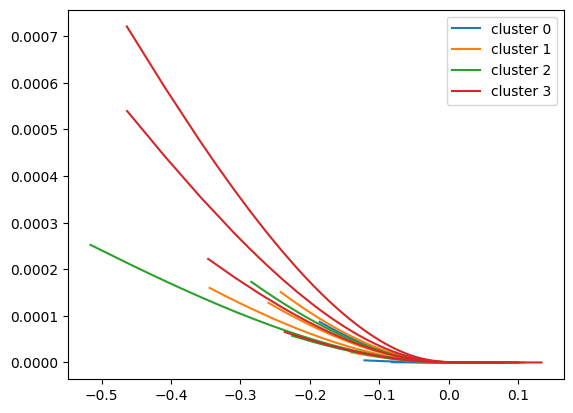

83
152
145
240
166
119
216
261
206
138
115
110
67
145
111
221


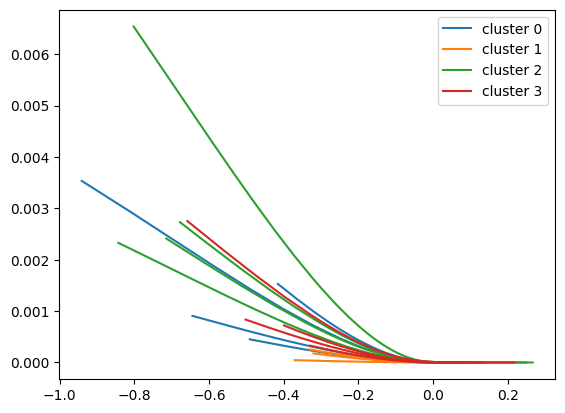

24
19
177
36
107
192
77
159
179
99
255
255
172
191
181
356


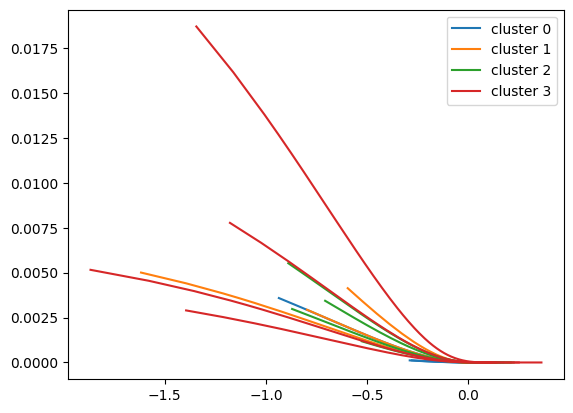

305
322
318
326
407
232
204
316
275
275
258
233
61
54
26
52


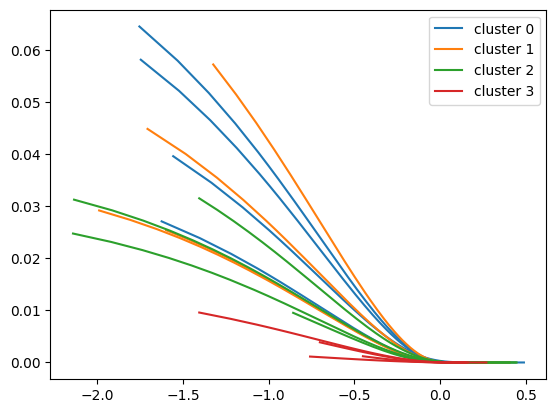

54
62
22
41
19
92
96
24
60
154
162
145
155
165
134
151


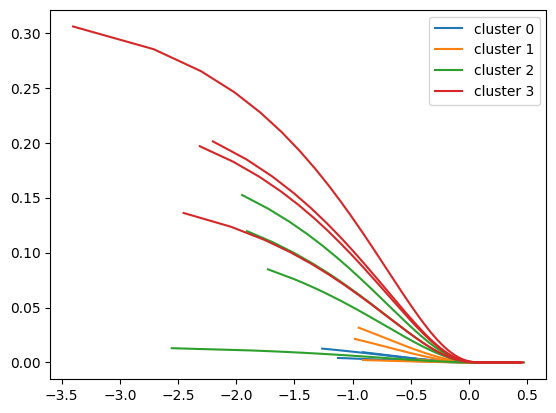

In [19]:
for groupID, (groupLabel, group) in enumerate(df.groupby("Group")):
    # if groupID != 4:
    #     continue
    
    keys = np.load(datapath / f"group_{groupID}_keys.npy", allow_pickle=True)
    labels = np.load(datapath / f"group_{groupID}_kmedoid_labels.npy")
    medoids = np.load(datapath / f"group_{groupID}_kmedoid_medoids.npy")
    # medoids = None
    sliceMatrix = np.load(datapath / f"group_{groupID}_slices.npy")
    
    data = group.groupby(["Date", "Texp"])
    
    # plotClusters(labels, sliceMatrix, groupLabel, None)
    plotSamples(labels, sliceMatrix, data, keys, 4)
    # plotClustersSingle(labels, sliceMatrix, groupLabel, None)
    # plotClustersMembers(labels, sliceMatrix, medoids, 2)
    # plotClustersMembersOrig(labels, data, keys, medoids, 2)

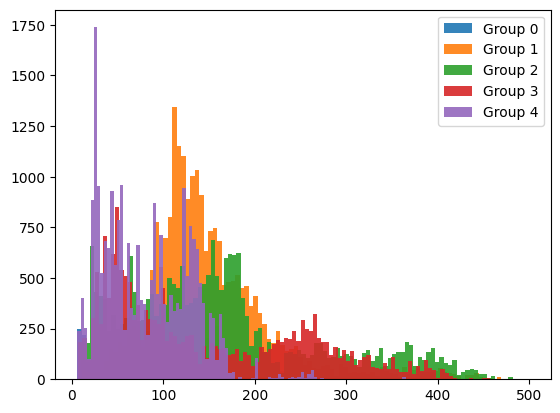

In [24]:
for groupID, (groupLabel, group) in enumerate(df.groupby("Group")):
    data = group.groupby(["Date", "Texp"]).size()
    plt.hist(data, bins=100, alpha=0.9, label=f"Group {groupID}")
plt.legend()